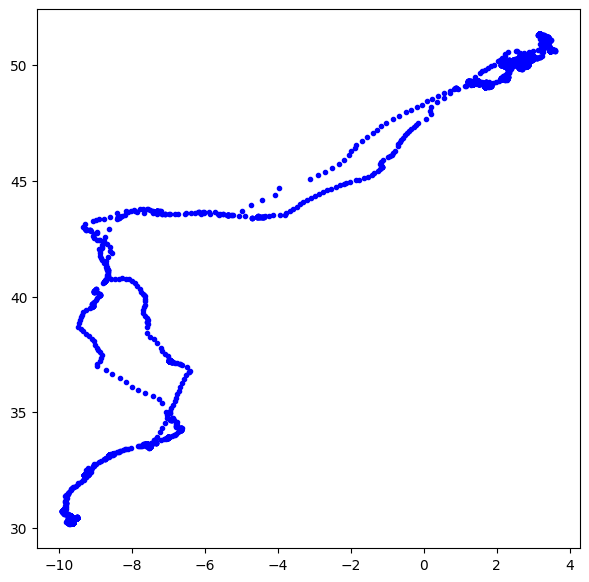

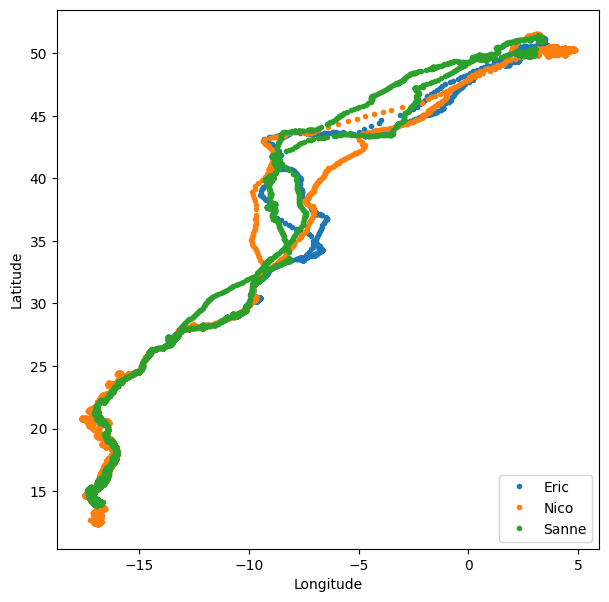

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


birddata = pd.read_csv("//content/bird_tracking.csv")
bird_names = pd.unique(birddata.bird_name)

# storing the indices of the bird Eric
ix = birddata.bird_name == "Eric"
x,y = birddata.longitude[ix], birddata.latitude[ix]
plt.figure(figsize = (7,7))
plt.plot(x,y,"b.")

''' To look at all the birds trajectories,
    we plot each bird in the same plot '''
plt.figure(figsize = (7,7))
for bird_name in bird_names:

    # storing the indices of the bird Eric
    ix = birddata.bird_name == bird_name
    x,y = birddata.longitude[ix], birddata.latitude[ix]
    plt.plot(x,y,".", label=bird_name)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(loc="lower right")
plt.show()

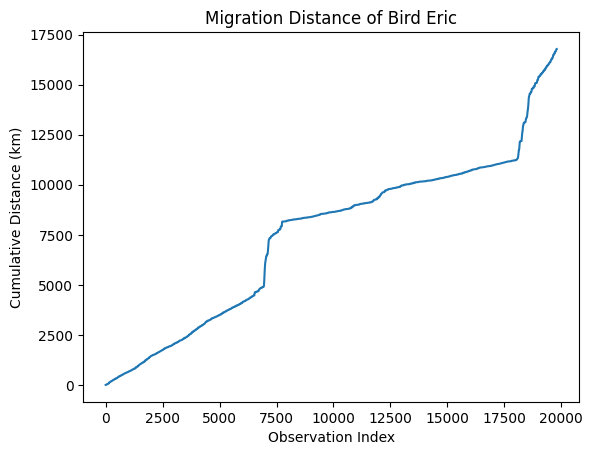

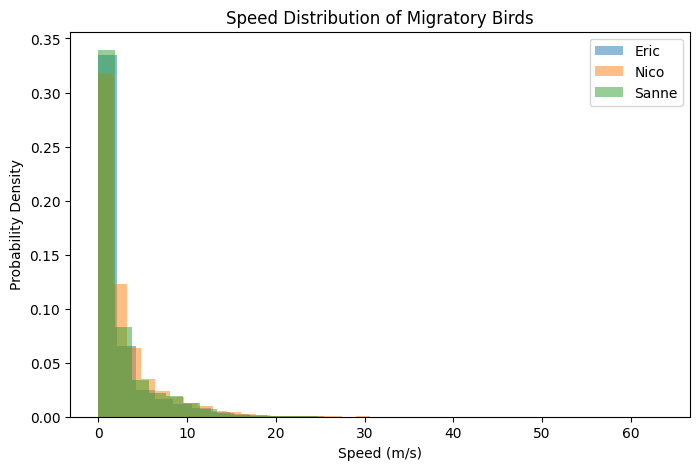

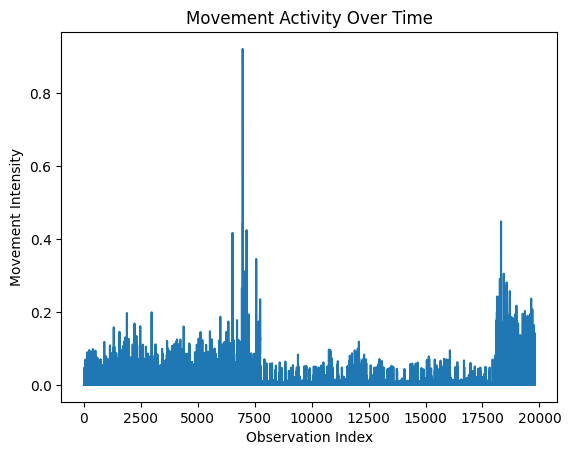

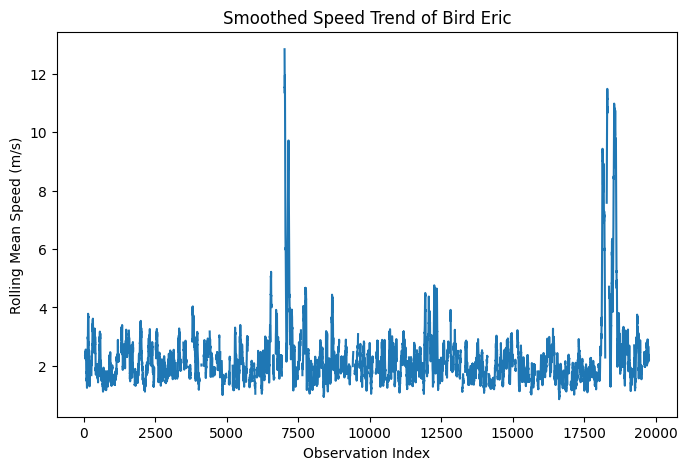

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 64.0 MB/s eta 0:00:00


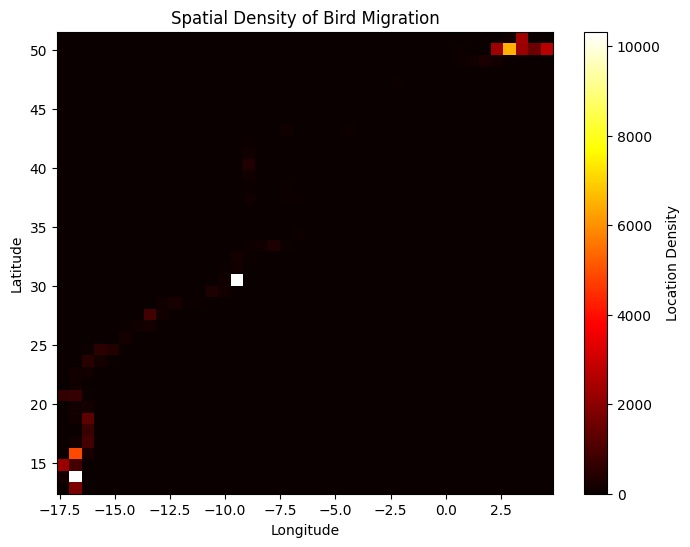

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.4 MB/s eta 0:00:00
  Attempting uninstall: pyshp
    Found existing installation: pyshp 3.0.3
    Uninstalling pyshp-3.0.3:
      Successfully uninstalled pyshp-3.0.3
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0


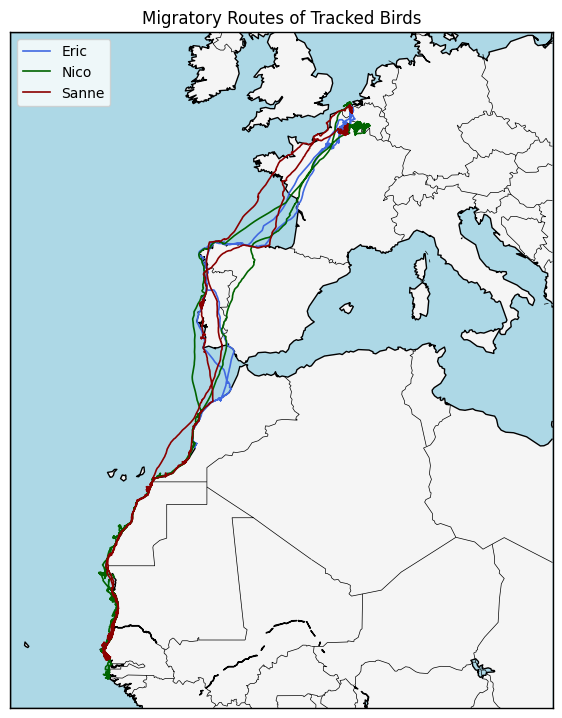

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

birddata = pd.read_csv("/content/bird_tracking.csv")

def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians,[lon1,lat1,lon2,lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))
    return 6371 * c  # km

data = birddata[birddata.bird_name=="Eric"]
distances = [0]

for i in range(1,len(data)):
    d = haversine(
        data.longitude.iloc[i-1], data.latitude.iloc[i-1],
        data.longitude.iloc[i],   data.latitude.iloc[i]
    )
    distances.append(distances[-1] + d)

plt.plot(distances)
plt.xlabel("Observation Index")
plt.ylabel("Cumulative Distance (km)")
plt.title("Migration Distance of Bird Eric")
plt.show()

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

for name in birddata.bird_name.unique():
    speed = birddata.speed_2d[birddata.bird_name==name]
    speed = speed[~np.isnan(speed)]
    plt.hist(speed, bins=30, alpha=0.5, density=True, label=name)

plt.xlabel("Speed (m/s)")
plt.ylabel("Probability Density")
plt.title("Speed Distribution of Migratory Birds")
plt.legend()
plt.show()

import datetime

birddata['timestamp'] = pd.to_datetime(
    birddata.date_time.str[:-3], format="%Y-%m-%d %H:%M:%S"
)

data = birddata[birddata.bird_name=="Eric"]
movement = np.sqrt(data.longitude.diff()**2 + data.latitude.diff()**2)

plt.plot(movement)
plt.xlabel("Observation Index")
plt.ylabel("Movement Intensity")
plt.title("Movement Activity Over Time")
plt.show()


window = 50  # smoothing window
rolling_speed = data.speed_2d.rolling(window).mean()

plt.figure(figsize=(8,5))
plt.plot(rolling_speed)
plt.xlabel("Observation Index")
plt.ylabel("Rolling Mean Speed (m/s)")
plt.title("Smoothed Speed Trend of Bird Eric")
plt.show()

!pip install cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.hist2d(
    birddata.longitude,
    birddata.latitude,
    bins=40,          # 🔥 reduced bins
    cmap='hot'
)

plt.colorbar(label="Location Density")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Density of Bird Migration")
plt.show()


!pip install basemap
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

birddata = pd.read_csv("/content/bird_tracking.csv")
bird_names = birddata.bird_name.unique()

plt.figure(figsize=(7,9))

m = Basemap(
    projection='merc',
    llcrnrlon=-25, llcrnrlat=10,
    urcrnrlon=20,  urcrnrlat=55,
    resolution='l'
)

m.drawcoastlines()
m.drawcountries()
m.fillcontinents(color='whitesmoke', lake_color='lightblue')
m.drawmapboundary(fill_color='lightblue')

colors = {"Eric":"royalblue", "Nico":"darkgreen", "Sanne":"darkred"}

for name in bird_names:
    data = birddata[birddata.bird_name == name]
    x, y = m(data.longitude.values, data.latitude.values)
    m.plot(x, y, '-', linewidth=1.2, color=colors[name], label=name)

plt.legend(loc="upper left")
plt.title("Migratory Routes of Tracked Birds")
plt.show()